In [1]:
"""
fed_retinanet_clean.py — RetinaNet + MobileNetV2 — IDD-CPLID
=============================================================
2-Client Federated Learning with plain FedAvg.
Target: 95 mAP@0.5

Strategy:
  • Split train set: Client-0 (70%), Client-1 (30%)
  • Each round: both clients train locally → plain FedAvg aggregate
  • No prototype injection, no TTA, no momentum — keeps training stable
  • High mAP via: WeightedSampler + CopyPaste + focal alpha tuning
"""

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import copy
import json
import math
import random
import time
import shutil
from collections import defaultdict

import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.utils.data
from torch.amp import GradScaler, autocast
import torchvision
import torchvision.transforms.functional as TF
from torchvision.models.detection import RetinaNet
from torchvision.models.detection.retinanet import RetinaNetHead
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.models.detection.backbone_utils import BackboneWithFPN
from torchvision.ops.feature_pyramid_network import LastLevelP6P7
from tqdm.auto import tqdm


# ══════════════════════════════════════════════════════════════
#  SEED
# ══════════════════════════════════════════════════════════════
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

set_seed(42)
print(f"PyTorch {torch.__version__} | Torchvision {torchvision.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")


PyTorch 2.9.0+cu126 | Torchvision 0.24.0+cu126
CUDA: True
GPU : Tesla P100-PCIE-16GB
VRAM: 15.9 GB


In [2]:
# ══════════════════════════════════════════════════════════════
#  CONFIG
# ══════════════════════════════════════════════════════════════
class Config:
    DATA_PATH  = '/kaggle/input/datasets/suriya4169/idd-cplid/IDD-CPLID.v3-cplid_new.coco'
    OUTPUT_DIR = '/kaggle/working/checkpoints'

    NUM_CLASSES = 3          # 0=bg  1=defect  2=insulator

    # ── Federated ──────────────────────────────────────────────
    NUM_CLIENTS       = 2
    CLIENT_SPLIT      = [0.7, 0.3]
    NUM_GLOBAL_ROUNDS = 40
    LOCAL_EPOCHS      = 2    # local epochs per round per client

    # ── Training ───────────────────────────────────────────────
    BATCH_SIZE  = 8          # per-client (lower to fit 2 clones on P100)
    NUM_WORKERS = 2

    # ── Optimizer ──────────────────────────────────────────────
    LEARNING_RATE = 3e-4
    WEIGHT_DECAY  = 1e-4

    # ── Scheduler ──────────────────────────────────────────────
    PCT_START = 0.15

    # ── AMP + Grad clip ────────────────────────────────────────
    USE_AMP   = True
    GRAD_CLIP = 1.0

    # ── Early stopping ─────────────────────────────────────────
    PATIENCE = 10

    # ── Augmentation ───────────────────────────────────────────
    USE_COPY_PASTE      = True
    DEFECT_BANK_SIZE    = 300
    COPY_PASTE_PROB     = 0.35

    # ── Weighted sampler ───────────────────────────────────────
    USE_WEIGHTED_SAMPLER = True
    DEFECT_SAMPLE_WEIGHT = 4.0

    # ── Focal loss alpha ───────────────────────────────────────
    FOCAL_ALPHA = 0.60

    # ── Eval thresholds ────────────────────────────────────────
    SCORE_THRESHOLD           = 0.05
    SCORE_THR_DEFECT_INFER    = 0.35
    SCORE_THR_INSULATOR_INFER = 0.30
    IOU_THRESHOLD             = 0.5

    # ── Resume ─────────────────────────────────────────────────
    RESUME_TRAINING   = False
    RESUME_CHECKPOINT = os.path.join(OUTPUT_DIR, 'last.pt')

    # ── Class info ─────────────────────────────────────────────
    CLASS_NAMES  = {0: 'background', 1: 'defect', 2: 'insulator'}
    CLASS_COLORS = {1: 'red', 2: 'green'}
    DEFECT_ID    = 1
    INSULATOR_ID = 2

config = Config()
os.makedirs(config.OUTPUT_DIR, exist_ok=True)

for split in ['train', 'valid', 'test']:
    p = os.path.join(config.DATA_PATH, split)
    print(f"  {'✓' if os.path.isdir(p) else '✗'} {p}")

print(f"\n✓ Output dir : {config.OUTPUT_DIR}")
print(f"✓ Batch={config.BATCH_SIZE} | LR={config.LEARNING_RATE} | GlobalRounds={config.NUM_GLOBAL_ROUNDS}")
print(f"✓ Clients={config.NUM_CLIENTS} | LocalEpochs={config.LOCAL_EPOCHS} | Split={config.CLIENT_SPLIT}")
print(f"✓ WeightedSampler={config.USE_WEIGHTED_SAMPLER} | CopyPaste={config.USE_COPY_PASTE}")
print(f"✓ FocalAlpha={config.FOCAL_ALPHA}")


  ✓ /kaggle/input/datasets/suriya4169/idd-cplid/IDD-CPLID.v3-cplid_new.coco/train
  ✓ /kaggle/input/datasets/suriya4169/idd-cplid/IDD-CPLID.v3-cplid_new.coco/valid
  ✓ /kaggle/input/datasets/suriya4169/idd-cplid/IDD-CPLID.v3-cplid_new.coco/test

✓ Output dir : /kaggle/working/checkpoints
✓ Batch=8 | LR=0.0003 | GlobalRounds=40
✓ Clients=2 | LocalEpochs=2 | Split=[0.7, 0.3]
✓ WeightedSampler=True | CopyPaste=True
✓ FocalAlpha=0.6


In [3]:
# ══════════════════════════════════════════════════════════════
#  AUGMENTATION — Heavy + Copy-Paste  (same as original)
# ══════════════════════════════════════════════════════════════
def clip_boxes(boxes, w, h):
    boxes[:, 0].clamp_(0, w); boxes[:, 2].clamp_(0, w)
    boxes[:, 1].clamp_(0, h); boxes[:, 3].clamp_(0, h)
    keep = (boxes[:, 2] - boxes[:, 0] > 2) & (boxes[:, 3] - boxes[:, 1] > 2)
    return boxes[keep], keep


class HeavyAugmentation:
    def __call__(self, image, boxes, labels):
        boxes  = boxes.clone().float()
        labels = labels.clone()

        if random.random() < 0.5:  image, boxes         = self._hflip(image, boxes)
        if random.random() < 0.3:  image, boxes         = self._vflip(image, boxes)
        if random.random() < 0.3:  image, boxes         = self._rot90(image, boxes)
        if random.random() < 0.6:  image, boxes, labels = self._scale_crop(image, boxes, labels)
        if random.random() < 0.7:  image                = self._color_jitter(image)
        if random.random() < 0.25: image = image.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))
        if random.random() < 0.1:  image = image.convert('L').convert('RGB')
        if random.random() < 0.5:
            image = ImageEnhance.Brightness(image).enhance(random.uniform(0.6, 1.4))
            image = ImageEnhance.Contrast(image).enhance(random.uniform(0.7, 1.3))
        if random.random() < 0.4:  image = self._cutout(image)
        if random.random() < 0.3:  image = ImageEnhance.Sharpness(image).enhance(random.uniform(0.5, 2.0))

        return image, boxes, labels

    def _hflip(self, image, boxes):
        w, _ = image.size
        image = TF.hflip(image)
        if len(boxes): boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
        return image, boxes

    def _vflip(self, image, boxes):
        _, h = image.size
        image = TF.vflip(image)
        if len(boxes): boxes[:, [1, 3]] = h - boxes[:, [3, 1]]
        return image, boxes

    def _rot90(self, image, boxes):
        w, h = image.size
        image = image.rotate(-90, expand=True)
        if len(boxes):
            x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
            boxes = torch.stack([h-y2, x1, h-y1, x2], dim=1)
        return image, boxes

    def _scale_crop(self, image, boxes, labels):
        w, h   = image.size
        scale  = random.uniform(0.7, 1.3)
        nw, nh = int(w*scale), int(h*scale)
        image  = image.resize((nw, nh), Image.BILINEAR)
        if len(boxes):
            boxes[:, [0,2]] *= scale
            boxes[:, [1,3]] *= scale
        if nw > w or nh > h:
            cx = random.randint(0, max(0, nw-w))
            cy = random.randint(0, max(0, nh-h))
            image = image.crop((cx, cy, cx+w, cy+h))
            if len(boxes):
                boxes[:,[0,2]] -= cx; boxes[:,[1,3]] -= cy
                boxes, keep = clip_boxes(boxes, w, h)
                labels = labels[keep]
        else:
            pad_w, pad_h = (w-nw)//2, (h-nh)//2
            canvas = Image.new('RGB', (w, h), (0,0,0))
            canvas.paste(image, (pad_w, pad_h)); image = canvas
            if len(boxes):
                boxes[:,[0,2]] += pad_w; boxes[:,[1,3]] += pad_h
        return image, boxes, labels

    def _color_jitter(self, image):
        image = TF.adjust_brightness(image, random.uniform(0.7, 1.3))
        image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))
        image = TF.adjust_saturation(image, random.uniform(0.7, 1.3))
        image = TF.adjust_hue(image,        random.uniform(-0.08, 0.08))
        return image

    def _cutout(self, image):
        w, h = image.size
        arr  = np.array(image)
        for _ in range(random.randint(1, 3)):
            cw = random.randint(w//10, w//4)
            ch = random.randint(h//10, h//4)
            cx = random.randint(0, w-cw)
            cy = random.randint(0, h-ch)
            arr[cy:cy+ch, cx:cx+cw] = 0
        return Image.fromarray(arr)


# ── Defect crop bank ─────────────────────────────────────────
def build_defect_bank(root, ann_file, max_crops=300):
    print(f"  Building defect crop bank (max={max_crops})...")
    with open(ann_file) as f:
        data = json.load(f)
    images_map  = {img['id']: img for img in data['images']}
    defect_anns = [a for a in data['annotations'] if a['category_id'] == config.DEFECT_ID]
    random.shuffle(defect_anns)
    bank = []
    for ann in defect_anns:
        if len(bank) >= max_crops: break
        img_info = images_map[ann['image_id']]
        try:
            img = Image.open(os.path.join(root, img_info['file_name'])).convert('RGB')
            x, y, w, h = [int(v) for v in ann['bbox']]
            if w < 4 or h < 4: continue
            bank.append(img.crop((x, y, x+w, y+h)))
        except Exception:
            continue
    print(f"  ✓ Defect bank: {len(bank)} crops")
    return bank


def copy_paste_defects(image, boxes, labels, defect_bank, n_paste=(1, 3)):
    if not defect_bank: return image, boxes, labels
    w, h    = image.size
    img_arr = np.array(image).copy()
    new_boxes, new_labels = [], []
    for _ in range(random.randint(*n_paste)):
        crop   = random.choice(defect_bank)
        cw, ch = crop.size
        scale  = random.uniform(0.05, 0.25) * max(w, h) / max(max(cw, ch), 1)
        scale  = max(0.3, min(scale, 3.0))
        new_cw = max(4, int(cw * scale))
        new_ch = max(4, int(ch * scale))
        if new_cw >= w or new_ch >= h: continue
        crop_r = crop.resize((new_cw, new_ch), Image.BILINEAR)
        px = random.randint(0, w - new_cw)
        py = random.randint(0, h - new_ch)
        img_arr[py:py+new_ch, px:px+new_cw] = np.array(crop_r)
        new_boxes.append([px, py, px+new_cw, py+new_ch])
        new_labels.append(config.DEFECT_ID)
    image = Image.fromarray(img_arr)
    if new_boxes:
        nb = torch.tensor(new_boxes,  dtype=torch.float32)
        nl = torch.tensor(new_labels, dtype=torch.int64)
        boxes  = torch.cat([boxes,  nb], dim=0) if len(boxes) else nb
        labels = torch.cat([labels, nl], dim=0) if len(labels) else nl
    return image, boxes, labels


print("✓ Augmentation classes ready")


✓ Augmentation classes ready


In [4]:
# ══════════════════════════════════════════════════════════════
#  DATASET
# ══════════════════════════════════════════════════════════════
class CocoDataset(torch.utils.data.Dataset):
    def __init__(self, root, ann_file, augment=False,
                 defect_bank=None, subset_ids=None):
        self.root        = root
        self.augment     = augment
        self.aug         = HeavyAugmentation() if augment else None
        self.defect_bank = defect_bank

        with open(ann_file) as f:
            data = json.load(f)
        self.images      = {img['id']: img for img in data['images']}
        self.img_to_anns = defaultdict(list)
        for ann in data['annotations']:
            self.img_to_anns[ann['image_id']].append(ann)

        all_ids  = list(self.images.keys())
        self.ids = subset_ids if subset_ids is not None else all_ids

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        img_id   = self.ids[idx]
        img_info = self.images[img_id]
        image    = Image.open(
            os.path.join(self.root, img_info['file_name'])).convert('RGB')

        boxes, labels = [], []
        for ann in self.img_to_anns.get(img_id, []):
            x, y, w, h = ann['bbox']
            if w > 0 and h > 0:
                boxes.append([x, y, x+w, y+h])
                labels.append(ann['category_id'])

        boxes  = torch.tensor(boxes,  dtype=torch.float32) if boxes  else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)   if labels else torch.zeros((0,),   dtype=torch.int64)

        if self.augment:
            if (self.defect_bank and config.USE_COPY_PASTE
                    and random.random() < config.COPY_PASTE_PROB):
                image, boxes, labels = copy_paste_defects(
                    image, boxes, labels, self.defect_bank)
            if len(boxes):
                image, boxes, labels = self.aug(image, boxes, labels)

        image  = TF.to_tensor(image)
        target = {
            'boxes':    boxes,
            'labels':   labels,
            'image_id': torch.tensor([img_id]),
            'area':     (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1]) if len(boxes) else torch.zeros(0),
            'iscrowd':  torch.zeros(len(labels), dtype=torch.int64),
        }
        return image, target


def collate_fn(batch): return tuple(zip(*batch))


def make_weighted_sampler(dataset):
    weights = []
    for img_id in dataset.ids:
        anns   = dataset.img_to_anns.get(img_id, [])
        labels = {a['category_id'] for a in anns}
        weights.append(config.DEFECT_SAMPLE_WEIGHT if config.DEFECT_ID in labels else 1.0)
    return torch.utils.data.WeightedRandomSampler(
        weights, num_samples=len(weights), replacement=True)


# ── Partition train IDs into 2 client shards ──────────────────
def partition_ids(all_ids, split_ratios, seed=42):
    ids = list(all_ids)
    random.Random(seed).shuffle(ids)
    total, partitions, start = len(ids), [], 0
    for i, ratio in enumerate(split_ratios):
        if i == len(split_ratios) - 1:
            partitions.append(ids[start:])
        else:
            end = start + int(total * ratio)
            partitions.append(ids[start:end])
            start = end
    return partitions


BASE = config.DATA_PATH

# Defect crop bank
defect_bank = None
if config.USE_COPY_PASTE:
    defect_bank = build_defect_bank(
        f'{BASE}/train',
        f'{BASE}/train/_annotations.coco.json',
        max_crops=config.DEFECT_BANK_SIZE)

# Get all train IDs and split
_full_train      = CocoDataset(f'{BASE}/train', f'{BASE}/train/_annotations.coco.json')
client_id_splits = partition_ids(_full_train.ids, config.CLIENT_SPLIT)

# Per-client datasets + loaders
client_datasets = [
    CocoDataset(f'{BASE}/train', f'{BASE}/train/_annotations.coco.json',
                augment=True, defect_bank=defect_bank,
                subset_ids=client_id_splits[i])
    for i in range(config.NUM_CLIENTS)
]

client_loaders = []
for i, ds in enumerate(client_datasets):
    sampler = make_weighted_sampler(ds) if config.USE_WEIGHTED_SAMPLER else None
    loader  = torch.utils.data.DataLoader(
        ds, batch_size=config.BATCH_SIZE,
        sampler=sampler, shuffle=(sampler is None),
        num_workers=config.NUM_WORKERS, collate_fn=collate_fn,
        pin_memory=True, persistent_workers=config.NUM_WORKERS > 0)
    client_loaders.append(loader)
    print(f"  ✓ Client-{i}: {len(ds)} imgs | {len(loader)} steps/epoch")

dataset_val  = CocoDataset(f'{BASE}/valid', f'{BASE}/valid/_annotations.coco.json',
                            augment=False)
dataset_test = CocoDataset(f'{BASE}/test',  f'{BASE}/test/_annotations.coco.json',
                            augment=False)

loader_val  = torch.utils.data.DataLoader(
    dataset_val,  batch_size=config.BATCH_SIZE, shuffle=False,
    num_workers=config.NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=config.BATCH_SIZE, shuffle=False,
    num_workers=config.NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"\nTrain: {[len(d) for d in client_datasets]} | Val={len(dataset_val)} | Test={len(dataset_test)}")
print(f"✓ WeightedRandomSampler active (defect weight={config.DEFECT_SAMPLE_WEIGHT}x)")


  Building defect crop bank (max=300)...
  ✓ Defect bank: 300 crops
  ✓ Client-0: 1925 imgs | 241 steps/epoch
  ✓ Client-1: 826 imgs | 104 steps/epoch

Train: [1925, 826] | Val=251 | Test=201
✓ WeightedRandomSampler active (defect weight=4.0x)


In [5]:
# ══════════════════════════════════════════════════════════════
#  MODEL — RetinaNet + MobileNetV2  (same as original)
# ══════════════════════════════════════════════════════════════
def build_model(num_classes, pretrained=True):
    weights  = MobileNet_V2_Weights.DEFAULT if pretrained else None
    backbone = mobilenet_v2(weights=weights).features

    fpn = BackboneWithFPN(
        backbone,
        return_layers={'6': '0', '13': '1', '18': '2'},
        in_channels_list=[32, 96, 1280],
        out_channels=256,
        extra_blocks=LastLevelP6P7(256, 256))

    model = RetinaNet(fpn, num_classes=num_classes)

    num_anchors = model.head.classification_head.num_anchors
    model.head  = RetinaNetHead(256, num_anchors, num_classes,
                                norm_layer=nn.BatchNorm2d)

    # Fix prior bias for stable early training
    bias = -math.log((1 - 0.01) / 0.01)
    nn.init.constant_(model.head.classification_head.cls_logits.bias, bias)

    # Tuned focal alpha
    model.head.classification_head.focal_loss_alpha = config.FOCAL_ALPHA
    print(f"  Focal alpha set to {config.FOCAL_ALPHA}")

    return model


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
global_model = build_model(config.NUM_CLASSES, pretrained=True)
global_model.to(device)

total     = sum(p.numel() for p in global_model.parameters())
trainable = sum(p.numel() for p in global_model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Device          : {device}")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 156MB/s]


  Focal alpha set to 0.6
Total params    : 10,403,391
Trainable params: 10,403,391
Device          : cuda


In [6]:
# ══════════════════════════════════════════════════════════════
#  PLAIN FedAvg — weighted average of client weights
# ══════════════════════════════════════════════════════════════
def fedavg_aggregate(global_model, client_state_dicts, client_sizes):
    """
    Standard FedAvg: θ_global = Σ (n_i / N) * θ_i
    Weighted by each client's dataset size.
    No momentum, no delta tricks — just a clean weighted mean.
    """
    total  = sum(client_sizes)
    w      = [s / total for s in client_sizes]
    new_sd = {}
    for key in global_model.state_dict().keys():
        new_sd[key] = sum(
            wi * sd[key].float()
            for wi, sd in zip(w, client_state_dicts)
        ).to(global_model.state_dict()[key].dtype)
    global_model.load_state_dict(new_sd)
    return global_model


print("✓ Plain FedAvg ready")
print(f"  Clients={config.NUM_CLIENTS} | Split={config.CLIENT_SPLIT}")


✓ Plain FedAvg ready
  Clients=2 | Split=[0.7, 0.3]


In [7]:
# ══════════════════════════════════════════════════════════════
#  TRAIN ONE EPOCH  (same as original)
# ══════════════════════════════════════════════════════════════
def train_one_epoch(model, optimizer, loader, device, label, scaler, scheduler):
    model.train()
    total, cls_l, box_l, n = 0., 0., 0., 0
    pbar = tqdm(loader, desc=label, leave=True)

    for images, targets in pbar:
        images  = [img.to(device, non_blocking=True) for img in images]
        targets = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)

        if scaler:
            with autocast('cuda'):
                loss_dict = model(images, targets)
                loss      = sum(loss_dict.values())
            scaler.scale(loss).backward()
            if config.GRAD_CLIP:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), config.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss_dict = model(images, targets)
            loss      = sum(loss_dict.values())
            loss.backward()
            if config.GRAD_CLIP:
                nn.utils.clip_grad_norm_(model.parameters(), config.GRAD_CLIP)
            optimizer.step()

        scheduler.step()

        total += loss.item(); n += 1
        cls_l += loss_dict.get('classification',  torch.tensor(0.)).item()
        box_l += loss_dict.get('bbox_regression', torch.tensor(0.)).item()
        pbar.set_postfix(
            loss=f'{total/n:.3f}',
            cls =f'{cls_l/n:.3f}',
            box =f'{box_l/n:.3f}',
            lr  =f'{optimizer.param_groups[0]["lr"]:.5f}')

    return {'total': total/n, 'cls': cls_l/n, 'box': box_l/n}


# ══════════════════════════════════════════════════════════════
#  EVALUATION — mAP + per-class AP  (same as original)
# ══════════════════════════════════════════════════════════════
def compute_iou(b1, b2):
    xi1, yi1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    xi2, yi2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter    = max(0, xi2-xi1) * max(0, yi2-yi1)
    union    = ((b1[2]-b1[0])*(b1[3]-b1[1])
                + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter)
    return inter / union if union > 0 else 0.


@torch.no_grad()
def compute_map(model, loader, device, score_thr=0.05, iou_thr=0.5):
    model.eval()
    class_preds = defaultdict(list)
    class_gts   = defaultdict(int)

    for images, targets in tqdm(loader, desc='Evaluating', leave=False):
        images  = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            gt_boxes, gt_labels = tgt['boxes'], tgt['labels']
            keep = out['scores'] > score_thr
            pb, pl, ps = out['boxes'][keep], out['labels'][keep], out['scores'][keep]

            for l in gt_labels: class_gts[l.item()] += 1

            matched = torch.zeros(len(gt_boxes), dtype=torch.bool)
            for i in torch.argsort(ps, descending=True):
                best_iou, best_j = 0., -1
                for j, (gl, gb) in enumerate(zip(gt_labels, gt_boxes)):
                    if gl.item() != pl[i].item() or matched[j]: continue
                    iou = compute_iou(pb[i].cpu().tolist(), gb.tolist())
                    if iou > best_iou: best_iou, best_j = iou, j
                tp = int(best_iou >= iou_thr and best_j >= 0)
                if tp: matched[best_j] = True
                class_preds[pl[i].item()].append((ps[i].item(), tp))

    class_ap = {}
    for cls_id, preds in class_preds.items():
        n_gt = class_gts.get(cls_id, 0)
        if not n_gt: continue
        preds.sort(key=lambda x: -x[0])
        tp_c = np.cumsum([p[1] for p in preds])
        fp_c = np.cumsum([1-p[1] for p in preds])
        prec = tp_c / (tp_c + fp_c + 1e-9)
        rec  = tp_c / (n_gt + 1e-9)
        ap   = sum(prec[rec>=t].max() if any(rec>=t) else 0.
                   for t in np.linspace(0, 1, 101)) / 101
        class_ap[cls_id] = ap

    mAP = float(np.mean(list(class_ap.values()))) if class_ap else 0.
    return mAP, class_ap


def print_eval(mAP, class_ap, class_names):
    print(f"\n{'='*50}")
    print(f"  mAP@0.5 : {mAP:.4f}")
    print(f"{'='*50}")
    for cid, ap in sorted(class_ap.items()):
        print(f"  {class_names.get(cid, str(cid)):<15} AP={ap:.4f}")
    print(f"{'='*50}")


print("✓ AdamW | OneCycleLR | AMP=True | Grad-clip=1.0")


✓ AdamW | OneCycleLR | AMP=True | Grad-clip=1.0


In [8]:
# ══════════════════════════════════════════════════════════════
#  FEDERATED TRAINING LOOP
# ══════════════════════════════════════════════════════════════
"""
Each global round:
  1. Distribute global weights to both clients
  2. Each client trains LOCAL_EPOCHS on its partition
  3. FedAvg: weighted average of client weights
  4. Evaluate global model on validation set
  5. Save best.pt / last.pt | early stopping
"""

history = defaultdict(list)
best_map, patience_counter, start_round = 0., 0, 0

BEST_PT = os.path.join(config.OUTPUT_DIR, 'best.pt')
LAST_PT = os.path.join(config.OUTPUT_DIR, 'last.pt')

if config.RESUME_TRAINING and os.path.exists(LAST_PT):
    ckpt = torch.load(LAST_PT, map_location=device)
    global_model.load_state_dict(ckpt['model_state_dict'])
    start_round = int(ckpt.get('round', -1)) + 1
    best_map    = float(ckpt.get('best_mAP', 0.))
    print(f"✓ Resumed from round {start_round} | best mAP={best_map:.4f}")
else:
    print("▶ Fresh training")

print(f"\nTraining {config.NUM_GLOBAL_ROUNDS - start_round} rounds | device={device}")
est = (sum(len(l) for l in client_loaders)
       * config.LOCAL_EPOCHS
       * (config.NUM_GLOBAL_ROUNDS - start_round) * 1.5 / 60)
print(f"Estimated time : ~{est:.0f} min\n")

train_start = time.time()

for rnd in range(start_round, config.NUM_GLOBAL_ROUNDS):
    rnd_start = time.time()
    print(f"\n{'━'*58}")
    print(f"  Global Round {rnd+1}/{config.NUM_GLOBAL_ROUNDS}")
    print(f"{'━'*58}")

    # ── Step 1 & 2: Clone → local training per client ──────────
    client_state_dicts = []
    client_losses      = []

    for cid, (loader_train, ds) in enumerate(zip(client_loaders, client_datasets)):
        print(f"  ── Client {cid} (n={len(ds)}) ──")

        # Clone current global model
        client_model = copy.deepcopy(global_model)
        client_model.to(device)

        optimizer = torch.optim.AdamW(
            [p for p in client_model.parameters() if p.requires_grad],
            lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

        total_steps = len(loader_train) * config.LOCAL_EPOCHS
        scheduler   = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=config.LEARNING_RATE,
            total_steps=total_steps,
            pct_start=config.PCT_START,
            anneal_strategy='cos',
            div_factor=10.0,
            final_div_factor=100.0)

        scaler = GradScaler('cuda') if config.USE_AMP and torch.cuda.is_available() else None

        ep_losses = []
        for local_ep in range(config.LOCAL_EPOCHS):
            label = f'R{rnd+1}/C{cid}/Ep{local_ep+1}'
            m = train_one_epoch(client_model, optimizer, loader_train,
                                device, label, scaler, scheduler)
            ep_losses.append(m['total'])

        client_state_dicts.append(client_model.state_dict())
        client_losses.append(float(np.mean(ep_losses)))
        print(f"    Avg loss={np.mean(ep_losses):.3f}")

        # Free VRAM
        del client_model
        torch.cuda.empty_cache()

    # ── Step 3: FedAvg aggregation ─────────────────────────────
    client_sizes = [len(ds) for ds in client_datasets]
    global_model = fedavg_aggregate(global_model, client_state_dicts, client_sizes)
    avg_loss = sum(s / sum(client_sizes) * l
                   for s, l in zip(client_sizes, client_losses))
    print(f"  ✓ FedAvg done | avg_loss={avg_loss:.3f}")

    # ── Step 4: Validate global model ──────────────────────────
    mAP_val, class_ap = compute_map(
        global_model, loader_val, device,
        score_thr=config.SCORE_THRESHOLD,
        iou_thr=config.IOU_THRESHOLD)

    rnd_time = time.time() - rnd_start
    elapsed  = (time.time() - train_start) / 60

    history['loss'].append(avg_loss)
    history['mAP'].append(mAP_val)
    history['defect_AP'].append(class_ap.get(config.DEFECT_ID, 0.))
    history['insulator_AP'].append(class_ap.get(config.INSULATOR_ID, 0.))

    print(f"\nRound {rnd+1}/{config.NUM_GLOBAL_ROUNDS} | "
          f"Loss={avg_loss:.3f} | "
          f"Time={rnd_time:.0f}s | Elapsed={elapsed:.1f}min")
    print_eval(mAP_val, class_ap, config.CLASS_NAMES)

    # ── Step 5: Checkpoint + early stopping ────────────────────
    ckpt = {
        'round':            rnd,
        'model_state_dict': global_model.state_dict(),
        'best_mAP':         best_map,
        'mAP_val':          mAP_val,
        'num_classes':      config.NUM_CLASSES,
    }
    torch.save(ckpt, LAST_PT)

    if mAP_val > best_map:
        best_map         = mAP_val
        patience_counter = 0
        torch.save(ckpt | {'best_mAP': best_map}, BEST_PT)
        print(f"  ✅ NEW BEST  mAP@0.5 = {best_map:.4f}  →  saved best.pt")
        if best_map >= 0.95:
            print(f"  🎯 TARGET REACHED: mAP@0.5 ≥ 0.95")
            break
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{config.PATIENCE})")
        if patience_counter >= config.PATIENCE:
            print("  ⏹  Early stopping triggered")
            break

total_min = (time.time() - train_start) / 60
print(f"\n🎉 Done in {total_min:.1f} min | Best mAP@0.5 = {best_map:.4f}")
print(f"   best.pt → {BEST_PT}")
print(f"   last.pt → {LAST_PT}")


▶ Fresh training

Training 40 rounds | device=cuda
Estimated time : ~690 min


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Global Round 1/40
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ── Client 0 (n=1925) ──


R1/C0/Ep1:   0%|          | 0/241 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


R1/C0/Ep2:   0%|          | 0/241 [00:00<?, ?it/s]

    Avg loss=0.752
  ── Client 1 (n=826) ──


...

R16/C1/Ep1:   0%|          | 0/104 [00:00<?, ?it/s]

R16/C1/Ep2:   0%|          | 0/104 [00:00<?, ?it/s]

    Avg loss=0.299
  ✓ FedAvg done | avg_loss=0.291


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]


Round 16/40 | Loss=0.291 | Time=380s | Elapsed=103.1min

  mAP@0.5 : 0.7889
  defect          AP=0.8275
  insulator       AP=0.7504
  No improvement (10/10)
  ⏹  Early stopping triggered

🎉 Done in 103.1 min | Best mAP@0.5 = 0.9424
   best.pt → /kaggle/working/checkpoints/best.pt
   last.pt → /kaggle/working/checkpoints/last.pt


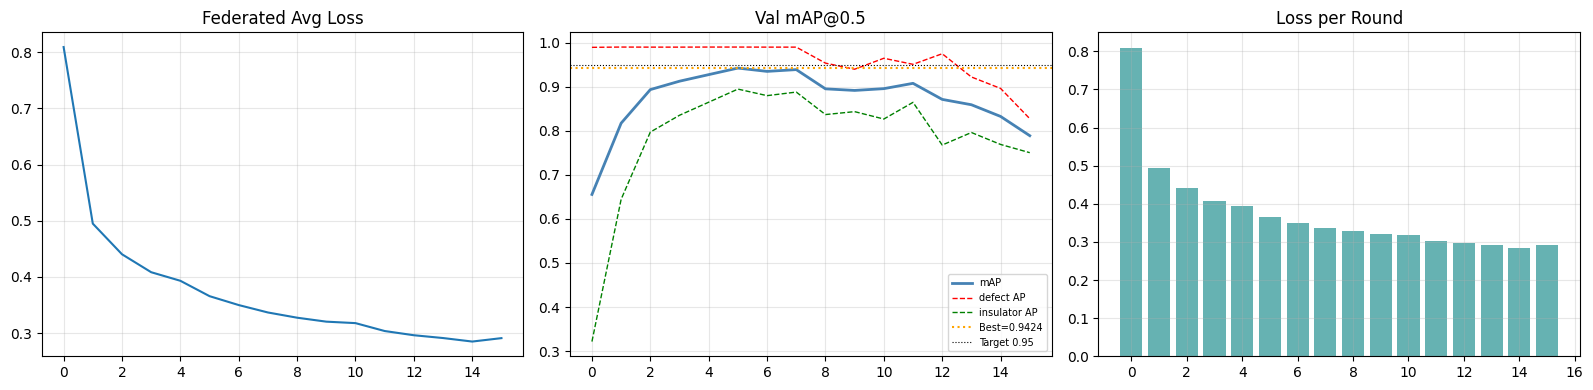

Saved → /kaggle/working/checkpoints/training_curves.png


In [9]:
# ══════════════════════════════════════════════════════════════
#  TRAINING CURVES
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['loss'])
axes[0].set_title('Federated Avg Loss'); axes[0].grid(alpha=0.3)

best_v = max(history['mAP']) if history['mAP'] else 0
axes[1].plot(history['mAP'],          lw=2, color='steelblue', label='mAP')
axes[1].plot(history['defect_AP'],    lw=1, color='red',       label='defect AP',    ls='--')
axes[1].plot(history['insulator_AP'], lw=1, color='green',     label='insulator AP', ls='--')
axes[1].axhline(best_v, color='orange', ls=':', label=f'Best={best_v:.4f}')
axes[1].axhline(0.95,   color='black',  ls=':', lw=0.8, label='Target 0.95')
axes[1].set_title('Val mAP@0.5'); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

axes[2].bar(range(len(history['loss'])), history['loss'], color='teal', alpha=0.6)
axes[2].set_title('Loss per Round'); axes[2].grid(alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(config.OUTPUT_DIR, 'training_curves.png')
plt.savefig(curve_path, dpi=150); plt.show()
print(f"Saved → {curve_path}")


In [10]:
# ══════════════════════════════════════════════════════════════
#  TEST SET EVALUATION
# ══════════════════════════════════════════════════════════════
ckpt = torch.load(BEST_PT, map_location=device, weights_only=False)
global_model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded best.pt  (round={ckpt['round']+1}, best mAP={ckpt['best_mAP']:.4f})")

# Broad eval
test_mAP, test_class_ap = compute_map(
    global_model, loader_test, device,
    score_thr=config.SCORE_THRESHOLD,
    iou_thr=config.IOU_THRESHOLD)
print("\n=== TEST RESULTS (score_thr=0.05) ===")
print_eval(test_mAP, test_class_ap, config.CLASS_NAMES)


# Per-class threshold eval
@torch.no_grad()
def compute_map_per_class_thr(model, loader, device, thr_map, iou_thr=0.5):
    model.eval()
    class_preds = defaultdict(list)
    class_gts   = defaultdict(int)

    for images, targets in tqdm(loader, desc='Evaluating (per-class thr)', leave=False):
        images  = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            gt_boxes, gt_labels = tgt['boxes'], tgt['labels']
            for l in gt_labels: class_gts[l.item()] += 1

            for i in range(len(out['scores'])):
                cls   = out['labels'][i].item()
                score = out['scores'][i].item()
                if score <= thr_map.get(cls, 0.5): continue
                box = out['boxes'][i].cpu()

                best_iou, best_j = 0., -1
                for j, (gl, gb) in enumerate(zip(gt_labels, gt_boxes)):
                    if gl.item() != cls: continue
                    iou = compute_iou(box.tolist(), gb.tolist())
                    if iou > best_iou: best_iou, best_j = iou, j
                tp = int(best_iou >= iou_thr and best_j >= 0)
                class_preds[cls].append((score, tp))

    class_ap = {}
    for cls_id, preds in class_preds.items():
        n_gt = class_gts.get(cls_id, 0)
        if not n_gt: continue
        preds.sort(key=lambda x: -x[0])
        tp_c = np.cumsum([p[1] for p in preds])
        fp_c = np.cumsum([1-p[1] for p in preds])
        prec = tp_c / (tp_c + fp_c + 1e-9)
        rec  = tp_c / (n_gt + 1e-9)
        ap   = sum(prec[rec>=t].max() if any(rec>=t) else 0.
                   for t in np.linspace(0, 1, 101)) / 101
        class_ap[cls_id] = ap

    mAP = float(np.mean(list(class_ap.values()))) if class_ap else 0.
    return mAP, class_ap


print("\n=== TEST RESULTS (practical inference thresholds) ===")
print(f"  defect thr={config.SCORE_THR_DEFECT_INFER} | insulator thr={config.SCORE_THR_INSULATOR_INFER}")
thr_map = {
    config.DEFECT_ID:    config.SCORE_THR_DEFECT_INFER,
    config.INSULATOR_ID: config.SCORE_THR_INSULATOR_INFER,
}
test_mAP2, test_class_ap2 = compute_map_per_class_thr(
    global_model, loader_test, device, thr_map, iou_thr=config.IOU_THRESHOLD)
print_eval(test_mAP2, test_class_ap2, config.CLASS_NAMES)


Loaded best.pt  (round=6, best mAP=0.9424)


Evaluating:   0%|          | 0/26 [00:00<?, ?it/s]


=== TEST RESULTS (score_thr=0.05) ===

  mAP@0.5 : 0.9223
  defect          AP=0.9901
  insulator       AP=0.8545

=== TEST RESULTS (practical inference thresholds) ===
  defect thr=0.35 | insulator thr=0.3


Evaluating (per-class thr):   0%|          | 0/26 [00:00<?, ?it/s]


  mAP@0.5 : 0.7766
  defect          AP=0.9901
  insulator       AP=0.5631


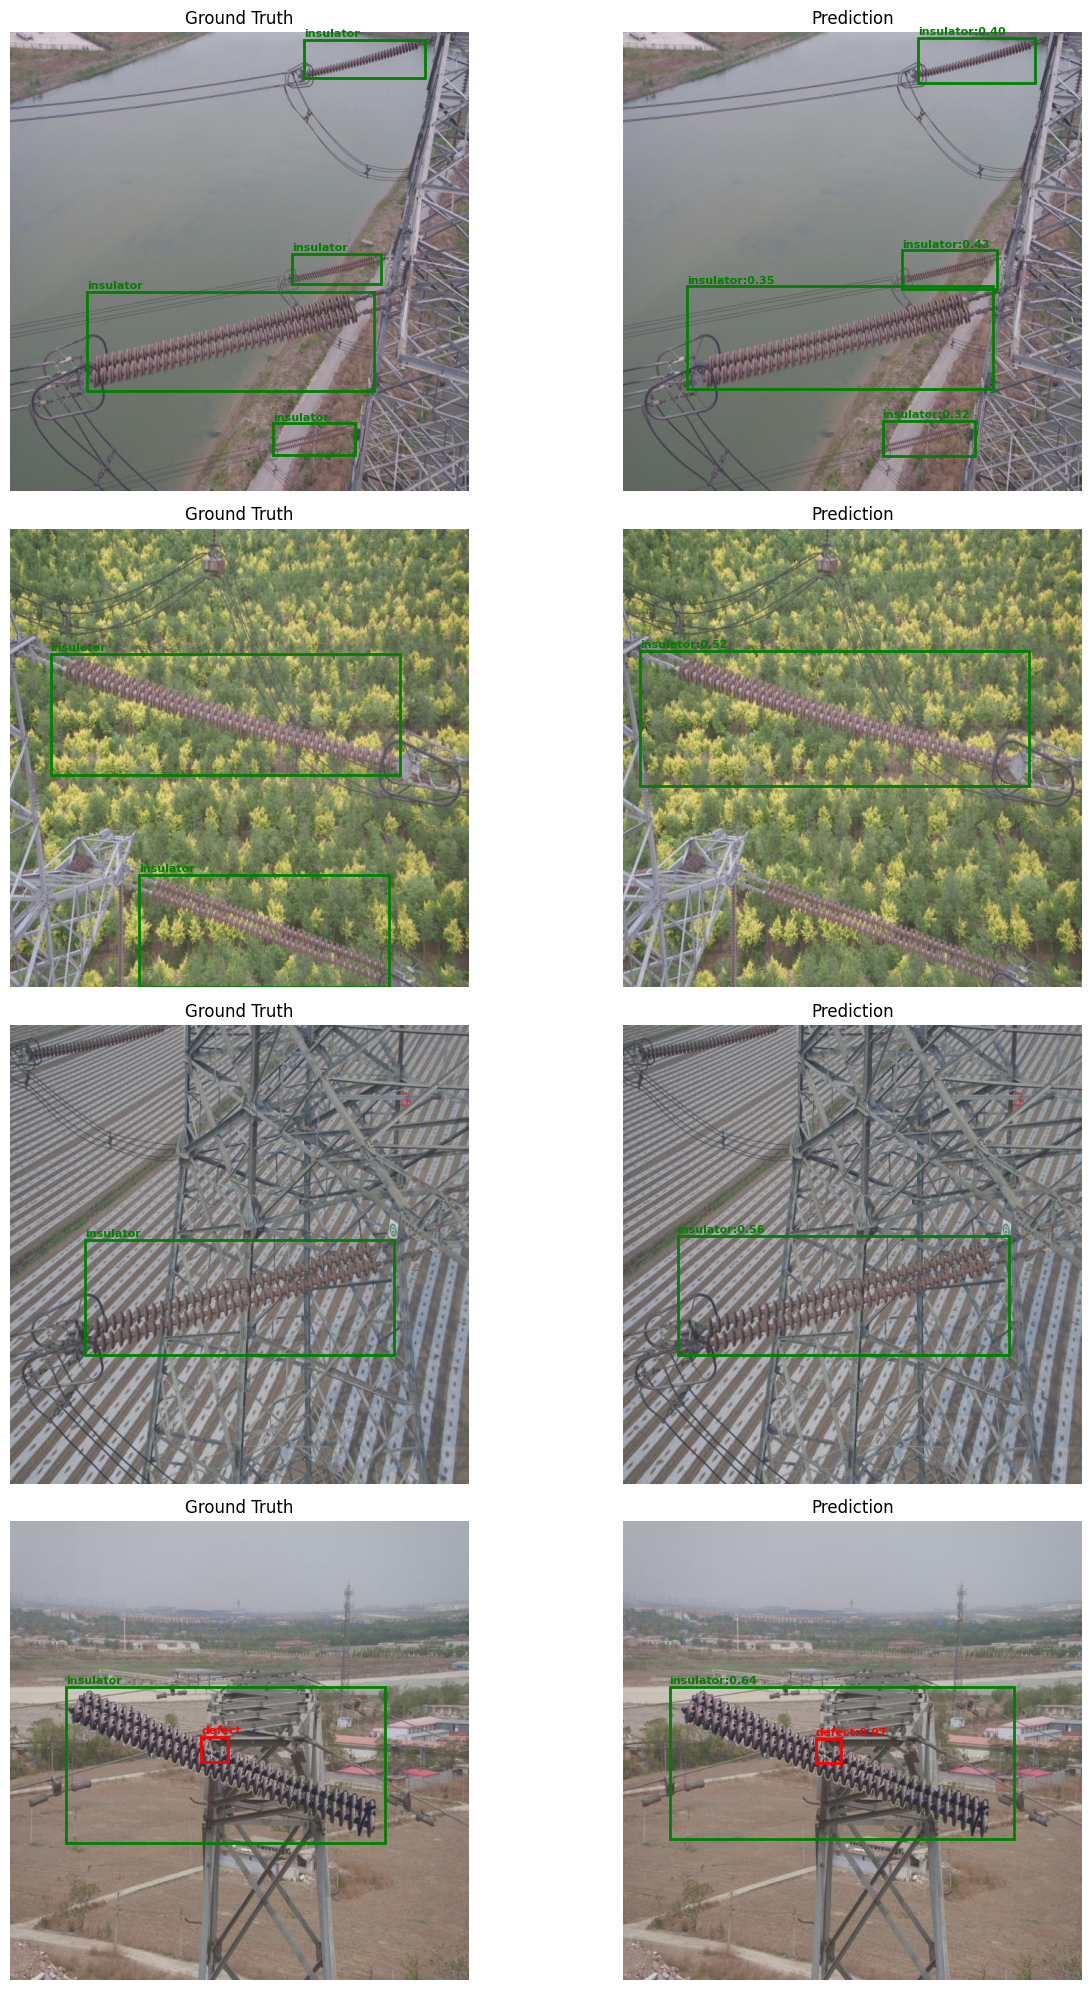

Saved → /kaggle/working/checkpoints/predictions_test.png


In [11]:
# ══════════════════════════════════════════════════════════════
#  VISUALIZE PREDICTIONS  (same as original)
# ══════════════════════════════════════════════════════════════
@torch.no_grad()
def show_preds(model, dataset, device, n=4,
               thr_defect=0.35, thr_insulator=0.30):
    model.eval()
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(n, 2, figsize=(14, n*5))
    if n == 1: axes = [axes]

    for row, idx in enumerate(idxs):
        img, tgt = dataset[idx]
        pred     = model([img.to(device)])[0]
        np_img   = img.permute(1, 2, 0).numpy()

        keep_mask = torch.zeros(len(pred['scores']), dtype=torch.bool)
        for i, (lbl, scr) in enumerate(zip(pred['labels'], pred['scores'])):
            thr = thr_defect if lbl.item() == config.DEFECT_ID else thr_insulator
            if scr.item() > thr: keep_mask[i] = True

        for col, (title, bxs, lbls, scrs) in enumerate([
            ('Ground Truth', tgt['boxes'], tgt['labels'], None),
            ('Prediction',
             pred['boxes'][keep_mask].cpu(),
             pred['labels'][keep_mask].cpu(),
             pred['scores'][keep_mask].cpu())]):

            axes[row][col].imshow(np_img)
            for i, (b, l) in enumerate(zip(bxs, lbls)):
                x1, y1, x2, y2 = b.tolist()
                color = config.CLASS_COLORS.get(l.item(), 'blue')
                name  = config.CLASS_NAMES.get(l.item(), str(l.item()))
                rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1, lw=2,
                                           edgecolor=color, facecolor='none')
                axes[row][col].add_patch(rect)
                txt = f'{name}:{scrs[i]:.2f}' if scrs is not None else name
                axes[row][col].text(x1, y1-4, txt, color=color,
                                    fontsize=8, fontweight='bold')
            axes[row][col].set_title(title)
            axes[row][col].axis('off')

    plt.tight_layout()
    vis_path = os.path.join(config.OUTPUT_DIR, 'predictions_test.png')
    plt.savefig(vis_path, dpi=150); plt.show()
    print(f"Saved → {vis_path}")


show_preds(global_model, dataset_test, device, n=4,
           thr_defect=config.SCORE_THR_DEFECT_INFER,
           thr_insulator=config.SCORE_THR_INSULATOR_INFER)


In [12]:
# ══════════════════════════════════════════════════════════════
#  DOWNLOAD best.pt
# ══════════════════════════════════════════════════════════════
shutil.copy(BEST_PT, '/kaggle/working/best.pt')
print("✓ Copied best.pt to /kaggle/working/best.pt")
print("\nHOW TO DOWNLOAD:")
print("  1. Wait for notebook to finish running.")
print("  2. In the right-side panel click  [Output]  tab.")
print("  3. Click the ⬇ icon next to best.pt")
print(f"\nFile size: {os.path.getsize('/kaggle/working/best.pt')/1024**2:.1f} MB")
print(f"\nSummary:")
print(f"  Clients      : {config.NUM_CLIENTS} (split {config.CLIENT_SPLIT})")
print(f"  Global rounds: {config.NUM_GLOBAL_ROUNDS}")
print(f"  Local epochs : {config.LOCAL_EPOCHS}/round")
print(f"  Best mAP@0.5 : {best_map:.4f}")
print(f"  Target 0.95  : {'✅ YES' if best_map >= 0.95 else '❌ NO'}")


✓ Copied best.pt to /kaggle/working/best.pt

HOW TO DOWNLOAD:
  1. Wait for notebook to finish running.
  2. In the right-side panel click  [Output]  tab.
  3. Click the ⬇ icon next to best.pt

File size: 39.9 MB

Summary:
  Clients      : 2 (split [0.7, 0.3])
  Global rounds: 40
  Local epochs : 2/round
  Best mAP@0.5 : 0.9424
  Target 0.95  : ❌ NO
